# A run into pandas

What a notebook wants from the board: a DataFrame with a time index and
one column per channel, scaled by the board's own calibration record.

**pandas is not a dependency of `coaxial`.** `daq.frame()` imports it
where it is called and refuses with the install line when it is absent,
so a bench that only reads a thermistor never has to have it. This file
does want it, and says so rather than failing three frames down.

In [1]:
import sys
import os

from pathlib import Path

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial import Coaxial63100                            # noqa: E402

try:
    import pandas                                           # noqa: F401
except ImportError:
    print('this example needs pandas: pip install pandas')
    raise SystemExit(0)

SIMULATED = True                    # False at the bench
PORT = 'COM4'
RECORDS = 200

## Take a run
`configure_buffer` sizes the circular buffer in RECORDS - the broker's
ring when one owns the port, so every other client reads the same
records from its own cursor.

In [2]:
with Coaxial63100(port=PORT, simulated_device=SIMULATED) as device:
    device.set_time_from_pc()
    daq = device.daq
    daq.enable()               # powers the analog front end

    daq.configure_buffer(10000)
    daq.configure('phaseU', 'phaseV', 'ntc', 'DC bus', sample_rate=500)

    with daq:                              # start, and stop however it ends
        rec = daq.read(RECORDS)

    df = daq.frame(rec)                    # time index, a column per channel
    scale = device.board.analog.scaling()  # the BOARD's calibration

print('%d records, %d columns, index %s' % (df.shape[0], df.shape[1],
                                            df.index.name))
print(df.head(4).to_string(float_format='%.1f'))

200 records, 14 columns, index time
                               Phase U  Phase V     NTC  DC bus  AFE_ON  nFAULT/TIM1_BKIN  KEEPALIVE  TIM1_CH1N/PWMUL  TIM1_CH1/PWMUH  TIM1_CH2N/PWMVL  TIM1_CH2/PWMVH  TIM1_CH3N/PWMWL  TIM1_CH3/PWMWH  dt
time                                                                                                                                                                                                       
2026-09-02 14:08:39.356410503  -7563.8  -4393.5 42298.3 24509.7     1.0               1.0        0.5              0.0             0.0              0.0             0.0              0.0             0.0 0.0
2026-09-02 14:08:39.358411312  -7536.2  -4388.7 42294.3 24521.5     1.0               1.0        0.5              0.0             0.0              0.0             0.0              0.0             0.0 0.0
2026-09-02 14:08:39.360411882  -7582.8  -4378.2 42291.7 24534.7     1.0               1.0        0.5              0.0             0.0              0

## Scale it
Codes are what the board sends. Every conversion lives in the
calibration record (invariant 7), so the numbers below come from the
board and not from a constant in this file.

In [3]:
df['NTC degC'] = df['NTC'].map(scale['ntc'].celsius)
df['U amps'] = df['Phase U'].map(scale['phase'].amps)
df['DC V'] = df['DC bus'].map(scale['dcbus'].volts)

print(df[['NTC degC', 'U amps', 'DC V']]
      .resample('100ms').mean().head(5).to_string(float_format='%.3f'))

                         NTC degC  U amps   DC V
time                                            
2026-09-02 14:08:39.300    41.659 -47.690 29.256
2026-09-02 14:08:39.400    41.977 -46.852 29.296
2026-09-02 14:08:39.500    42.417 -44.905 29.348
2026-09-02 14:08:39.600    42.854 -42.162 29.401
2026-09-02 14:08:39.700    43.254 -38.913 29.439


## What the clock actually did
`dt` is measured, from the gap to the next record - not the rate that
was asked for. Its spread is what says whether the loop kept up.

In [4]:
print('dt: mean %.6f s, std %.2e, min %.6f, max %.6f'
      % (df['dt'].mean(), df['dt'].std(), df['dt'].min(), df['dt'].max()))

dt: mean 0.002001 s, std 1.13e-07, min 0.002001, max 0.002001


## And a picture
Inline, and nowhere else: an example that wrote image files littered
the repository with them. Anything more than this line is pandas' own.

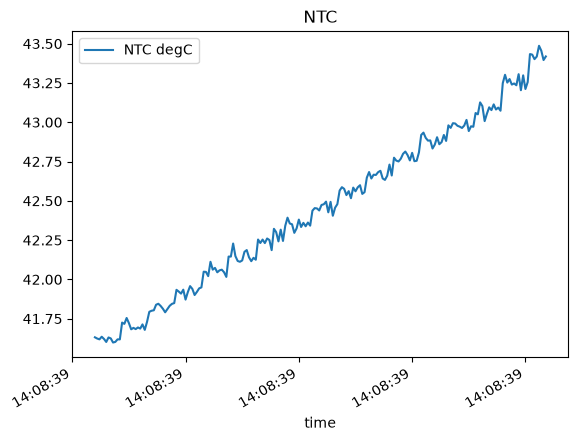

In [5]:
df[['NTC degC']].plot(title='NTC');